# Figure 1a: Original Space vs Pseudo Space

Reproduce a Figure 1a-style visualization for the Xenium TgCRND8 17.9 months sample.

**Left panel**: Original Xenium physical coordinates (`cell_position_x`, `cell_position_y`)

**Right panel**: scSpace-reconstructed pseudo-space coordinates (`pseudo_dim_0`, `pseudo_dim_1`)

**Color**: scSpace cluster labels (16 clusters)

Reference: scSpace paper Figure 1a (DLPFC)

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# ── Paths ──
SC_META = Path("../../_l_result/processed/xenium_sc_meta.csv")
PSEUDO = Path("../../_l_result/xenium_output/pseudo_space.csv")
CLUSTERING = Path("../../_l_result/xenium_output/clustering.csv")
OUTPUT = Path("../../_l_result/figure1/fig1_original_vs_pseudo_space.png")
DPI = 150
POINT_SIZE = 3
ALPHA = 0.7

In [3]:
# ── Load and merge ──
sc_meta = pd.read_csv(SC_META, index_col=0)
pseudo = pd.read_csv(PSEUDO, index_col=0)
clustering = pd.read_csv(CLUSTERING, index_col=0)

df = (
    sc_meta[["cell_position_x", "cell_position_y"]]
    .join(pseudo)
    .join(clustering)
)
df["scSpace"] = df["scSpace"].astype(str)

print(f"Loaded {len(df)} cells, {df['scSpace'].nunique()} clusters.")

Loaded 2000 cells, 14 clusters.


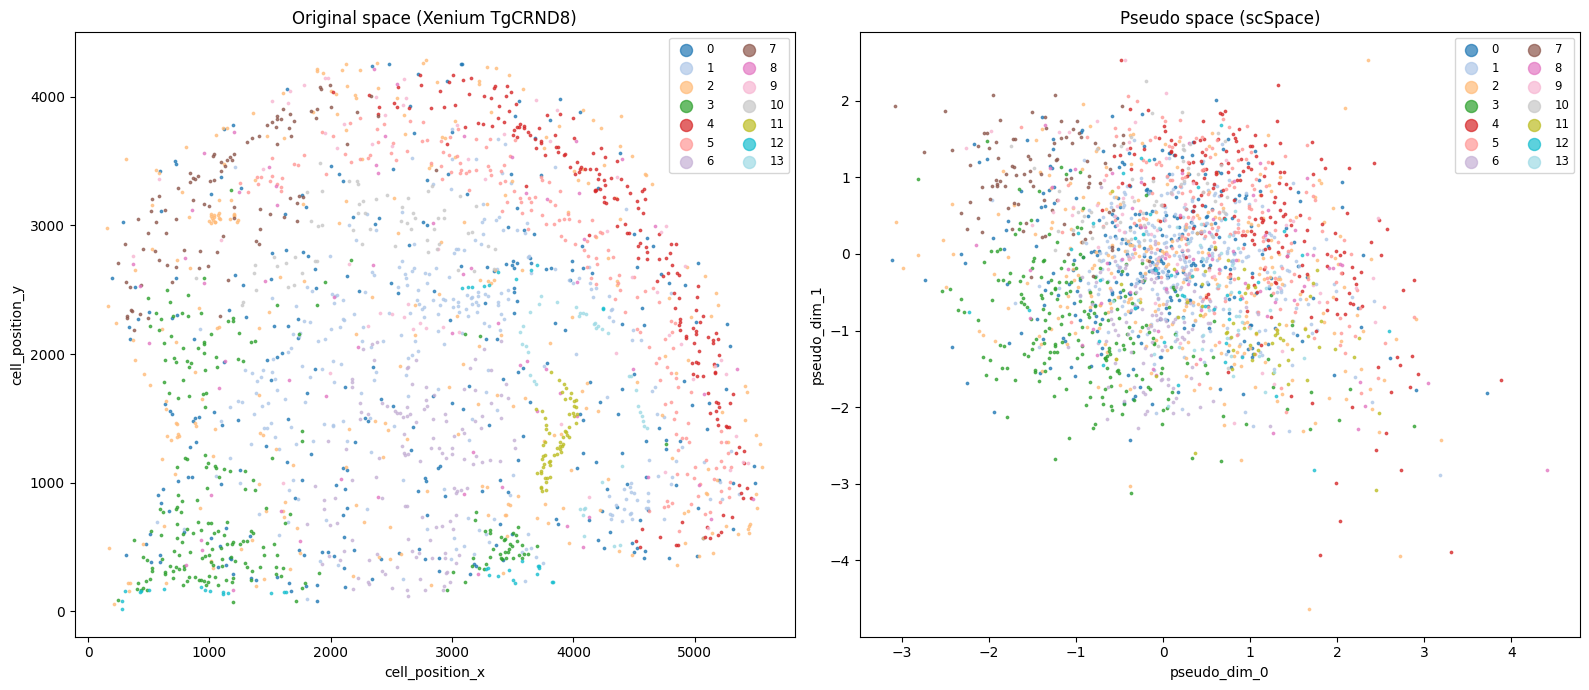

Figure saved to ../../_l_result/figure1/fig1_original_vs_pseudo_space.png


In [6]:
# ── Plot ──
clusters = sorted(df["scSpace"].unique(), key=int)
colors = plt.cm.tab20(np.linspace(0, 1, len(clusters)))
color_map = dict(zip(clusters, colors))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: original Xenium space
for cl in clusters:
    mask = df["scSpace"] == cl
    ax1.scatter(
        df.loc[mask, "cell_position_x"],
        df.loc[mask, "cell_position_y"],
        c=[color_map[cl]], s=POINT_SIZE, alpha=ALPHA, label=cl,
    )
ax1.set_title("Original space (Xenium TgCRND8)")
ax1.set_xlabel("cell_position_x")
ax1.set_ylabel("cell_position_y")
ax1.legend(markerscale=5, fontsize="small", ncol=2, loc="upper right")

# Right: pseudo space
for cl in clusters:
    mask = df["scSpace"] == cl
    ax2.scatter(
        df.loc[mask, "pseudo_dim_0"],
        df.loc[mask, "pseudo_dim_1"],
        c=[color_map[cl]], s=POINT_SIZE, alpha=ALPHA, label=cl,
    )
ax2.set_title("Pseudo space (scSpace)")
ax2.set_xlabel("pseudo_dim_0")
ax2.set_ylabel("pseudo_dim_1")
ax2.legend(markerscale=5, fontsize="small", ncol=2, loc="upper right")

fig.tight_layout()
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT, dpi=DPI)
plt.show()
plt.close(fig)
print(f"Figure saved to {OUTPUT}")

In [ ]:
# ── Inline display ──
from IPython.display import Image, display
display(Image(OUTPUT))

## Observations

- The **original space** shows the actual tissue morphology (cell positions in the Xenium field of view).
- The **pseudo space** shows the scSpace-reconstructed coordinates.
- Colors represent the same scSpace cluster labels in both panels.
- Compare how clusters that are spatially coherent in the original space are organized in the pseudo space.